In [ ]:
# !pip install transformers timm accelerate datasets

In [ ]:
# from transformers import ViTMAEForPreTraining

# model = ViTMAEForPreTraining.from_pretrained(
#     "facebook/vit-mae-base"
# )

In [ ]:
import os
import glob
import torch
import numpy as np

from PIL import Image
from tqdm import tqdm

from torch.utils.data import Dataset, DataLoader
from torchvision import transforms

from transformers import (
    ViTMAEForPreTraining,
    ViTMAEModel,
)

from google.colab import drive

In [ ]:
# drive.mount('/content/drive')

In [ ]:
class CFG:
    # Path containing embryo images
    DATASET_PATH = "/content/drive/MyDrive/AI-Embryo/all_embryo"

    # Training
    IMAGE_SIZE   = 224
    BATCH_SIZE   = 128
    EPOCHS       = 40
    LR           = 1e-4
    NUM_WORKERS  = 2
    DEVICE       = "cuda" if torch.cuda.is_available() else "cpu"

    # Save / resume paths
    SAVE_DIR          = "/content/drive/MyDrive/embryo_mae"

    # Set to a .pth path to resume from that checkpoint,
    # or leave as None to auto-detect the latest checkpoint in SAVE_DIR.
    RESUME_CHECKPOINT = RESUME_CHECKPOINT = "/content/drive/MyDrive/embryo_mae/best_mae_full_model.pth"


os.makedirs(CFG.SAVE_DIR, exist_ok=True)
print("DEVICE:", CFG.DEVICE)

DEVICE: cuda


In [ ]:
transform = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(5),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std =[0.229, 0.224, 0.225],
    ),
])

In [ ]:
class EmbryoDataset(Dataset):
    def __init__(self, folder, transform=None):
        self.folder    = folder
        self.transform = transform

        valid_ext = {".jpg", ".jpeg", ".png", ".bmp"}
        self.image_paths = [
            os.path.join(folder, f)
            for f in os.listdir(folder)
            if os.path.splitext(f.lower())[1] in valid_ext
        ]
        print(f"Found {len(self.image_paths)} images")

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        image = Image.open(self.image_paths[idx]).convert("RGB")
        if self.transform:
            image = self.transform(image)
        return image


dataset = EmbryoDataset(CFG.DATASET_PATH, transform=transform)

loader = DataLoader(
    dataset,
    batch_size=CFG.BATCH_SIZE,
    shuffle=True,
    num_workers=CFG.NUM_WORKERS,
    pin_memory=True,
)

Found 2344 images


In [ ]:
def find_latest_checkpoint(save_dir):
    """Return the path of the highest-epoch checkpoint, or None."""
    pattern = os.path.join(save_dir, "mae_epoch_*.pth")
    checkpoints = glob.glob(pattern)
    if not checkpoints:
        return None
    # Sort by epoch number embedded in filename
    checkpoints.sort(key=lambda p: int(p.split("_epoch_")[-1].replace(".pth", "")))
    return checkpoints[-1]


print("Loading pretrained MAE from facebook/vit-mae-base ...")
model = ViTMAEForPreTraining.from_pretrained("facebook/vit-mae-base")

# ── Resolve checkpoint ──────────────────────────────────────────────────────
resume_path = CFG.RESUME_CHECKPOINT or find_latest_checkpoint(CFG.SAVE_DIR)
start_epoch = 0

if resume_path and os.path.isfile(resume_path):
    print(f"\nResuming from checkpoint: {resume_path}")
    checkpoint = torch.load(resume_path, map_location=CFG.DEVICE, weights_only=True)

    # Support both plain state-dict saves and dict-based checkpoint saves
    if isinstance(checkpoint, dict) and "model_state_dict" in checkpoint:
        model.load_state_dict(checkpoint["model_state_dict"])
        start_epoch = checkpoint.get("epoch", 0)       # resume epoch index
        print(f"Resumed at epoch {start_epoch}")
    else:
        # Plain state-dict (your original save format)
        model.load_state_dict(checkpoint)
        # Try to infer epoch from filename
        try:
            start_epoch = int(resume_path.split("_epoch_")[-1].replace(".pth", ""))
        except ValueError:
            start_epoch = 0
        print(f"Weights loaded. Continuing from epoch {start_epoch + 1}")
else:
    print("No checkpoint found — starting from pretrained weights.")

model = model.to(CFG.DEVICE)
print("Model ready on", CFG.DEVICE)

Loading pretrained MAE from facebook/vit-mae-base ...


Loading weights:   0%|          | 0/334 [00:00<?, ?it/s]


Resuming from checkpoint: /content/drive/MyDrive/embryo_mae/best_mae_full_model.pth
Resumed at epoch 19
Model ready on cuda


In [ ]:
optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=CFG.LR,
    weight_decay=0.05,
)

# Cosine annealing over the remaining epochs
remaining_epochs = CFG.EPOCHS - start_epoch
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer,
    T_max=remaining_epochs,
    eta_min=1e-6,
)

In [ ]:
# FIX: use torch.amp instead of the deprecated torch.cuda.amp
scaler = torch.amp.GradScaler("cuda")

best_loss = float("inf")

for epoch in range(start_epoch, CFG.EPOCHS):
    model.train()
    running_loss = 0.0
    progress_bar = tqdm(loader, desc=f"Epoch {epoch+1}/{CFG.EPOCHS}")

    for images in progress_bar:
        images = images.to(CFG.DEVICE, non_blocking=True)

        optimizer.zero_grad()

        # FIX: use torch.amp.autocast instead of torch.cuda.amp.autocast
        with torch.amp.autocast("cuda"):
            outputs = model(pixel_values=images)
            loss = outputs.loss

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        running_loss += loss.item()
        progress_bar.set_postfix(loss=f"{loss.item():.4f}")

    scheduler.step()                      # update LR each epoch

    epoch_loss = running_loss / len(loader)
    current_lr = scheduler.get_last_lr()[0]
    print(f"\nEpoch {epoch+1} | Avg Loss: {epoch_loss:.4f} | LR: {current_lr:.2e}")

    # ── Save best model ────────────────────────────────────────────────────
    if epoch_loss < best_loss:
        best_loss = epoch_loss
        best_path = os.path.join(CFG.SAVE_DIR, "best_mae_full_model.pth")
        # Save richer checkpoint so resuming is fully stateful
        torch.save({
            "epoch": epoch + 1,
            "model_state_dict": model.state_dict(),
            "optimizer_state_dict": optimizer.state_dict(),
            "loss": best_loss,
        }, best_path)
        print(f"  ✓ Best model saved (loss={best_loss:.4f})")

    # ── Save epoch checkpoint ──────────────────────────────────────────────
    ckpt_path = os.path.join(CFG.SAVE_DIR, f"mae_epoch_{epoch+1}.pth")
    torch.save({
        "epoch": epoch + 1,
        "model_state_dict": model.state_dict(),
        "optimizer_state_dict": optimizer.state_dict(),
        "loss": epoch_loss,
    }, ckpt_path)
    print(f"  ✓ Checkpoint saved → {ckpt_path}")

print("\nTraining complete.")

Epoch 20/40: 100%|██████████| 19/19 [00:58<00:00,  3.10s/it, loss=0.0910]



Epoch 20 | Avg Loss: 0.0973 | LR: 9.94e-05
  ✓ Best model saved (loss=0.0973)
  ✓ Checkpoint saved → /content/drive/MyDrive/embryo_mae/mae_epoch_20.pth


Epoch 21/40: 100%|██████████| 19/19 [01:18<00:00,  4.12s/it, loss=0.0871]



Epoch 21 | Avg Loss: 0.0919 | LR: 9.78e-05
  ✓ Best model saved (loss=0.0919)
  ✓ Checkpoint saved → /content/drive/MyDrive/embryo_mae/mae_epoch_21.pth


Epoch 22/40: 100%|██████████| 19/19 [01:24<00:00,  4.45s/it, loss=0.0943]


...


Epoch 38 | Avg Loss: 0.0880 | LR: 3.20e-06
  ✓ Checkpoint saved → /content/drive/MyDrive/embryo_mae/mae_epoch_38.pth


Epoch 39/40: 100%|██████████| 19/19 [00:49<00:00,  2.59s/it, loss=0.0855]



Epoch 39 | Avg Loss: 0.0871 | LR: 1.55e-06
  ✓ Best model saved (loss=0.0871)
  ✓ Checkpoint saved → /content/drive/MyDrive/embryo_mae/mae_epoch_39.pth


Epoch 40/40: 100%|██████████| 19/19 [00:52<00:00,  2.78s/it, loss=0.0825]



Epoch 40 | Avg Loss: 0.0870 | LR: 1.00e-06
  ✓ Best model saved (loss=0.0870)
  ✓ Checkpoint saved → /content/drive/MyDrive/embryo_mae/mae_epoch_40.pth

Training complete.


In [ ]:
print("Saving encoder only...")

# model.vit is the ViTMAEModel encoder inside ViTMAEForPreTraining
encoder = model.vit

encoder_path = os.path.join(CFG.SAVE_DIR, "embryo_mae_encoder.pth")
torch.save(encoder.state_dict(), encoder_path)

print(f"Encoder saved → {encoder_path}")

Saving encoder only...
Encoder saved → /content/drive/MyDrive/embryo_mae/embryo_mae_encoder.pth


In [ ]:
print("\nTesting feature extraction with saved encoder...")

# Load the encoder architecture then inject the fine-tuned weights
feature_extractor = ViTMAEModel.from_pretrained("facebook/vit-mae-base")
feature_extractor.load_state_dict(
    torch.load(encoder_path, map_location=CFG.DEVICE, weights_only=True)
)
feature_extractor = feature_extractor.to(CFG.DEVICE)
feature_extractor.eval()

sample_image = dataset[0].unsqueeze(0).to(CFG.DEVICE)

with torch.no_grad():
    outputs      = feature_extractor(pixel_values=sample_image)
    features     = outputs.last_hidden_state   # (1, num_patches+1, hidden_dim)
    cls_embedding = features[:, 0]             # CLS token

print("CLS embedding shape:", cls_embedding.shape)

# Save features for the full dataset (optional — comment out if not needed)
all_features = []
feature_extractor.eval()

with torch.no_grad():
    for batch in tqdm(loader, desc="Extracting features"):
        batch = batch.to(CFG.DEVICE)
        out   = feature_extractor(pixel_values=batch)
        cls   = out.last_hidden_state[:, 0].cpu()
        all_features.append(cls)

all_features = torch.cat(all_features, dim=0)   # (N, hidden_dim)

feature_save_path = os.path.join(CFG.SAVE_DIR, "embryo_features.pt")
torch.save(all_features, feature_save_path)
print(f"Features saved → {feature_save_path}")
print(f"Feature tensor shape: {all_features.shape}")


Testing feature extraction with saved encoder...


Loading weights:   0%|          | 0/198 [00:00<?, ?it/s]

ViTMAEModel LOAD REPORT from: facebook/vit-mae-base
Key                                                                              | Status     |  | 
---------------------------------------------------------------------------------+------------+--+-
decoder.decoder_layers.{0, 1, 2, 3, 4, 5, 6, 7}.intermediate.dense.bias          | UNEXPECTED |  | 
decoder.decoder_pred.weight                                                      | UNEXPECTED |  | 
decoder.decoder_layers.{0, 1, 2, 3, 4, 5, 6, 7}.attention.attention.key.bias     | UNEXPECTED |  | 
decoder.decoder_layers.{0, 1, 2, 3, 4, 5, 6, 7}.layernorm_after.bias             | UNEXPECTED |  | 
decoder.decoder_layers.{0, 1, 2, 3, 4, 5, 6, 7}.attention.attention.value.weight | UNEXPECTED |  | 
decoder.decoder_norm.bias                                                        | UNEXPECTED |  | 
decoder.decoder_layers.{0, 1, 2, 3, 4, 5, 6, 7}.layernorm_before.bias            | UNEXPECTED |  | 
decoder.decoder_layers.{0, 1, 2, 3, 4, 5, 6, 7}.

CLS embedding shape: torch.Size([1, 768])


Extracting features: 100%|██████████| 19/19 [01:04<00:00,  3.37s/it]


Features saved → /content/drive/MyDrive/embryo_mae/embryo_features.pt
Feature tensor shape: torch.Size([2344, 768])


In [ ]:
print("\n===================================")
print("TRAINING COMPLETE")
print("===================================")

print("\nSaved files:")
print("  1. Best full MAE model :", os.path.join(CFG.SAVE_DIR, "best_mae_full_model.pth"))
print("  2. Encoder weights     :", encoder_path)
print("  3. Feature embeddings  :", feature_save_path)
print("\nDone.")


TRAINING COMPLETE

Saved files:
  1. Best full MAE model : /content/drive/MyDrive/embryo_mae/best_mae_full_model.pth
  2. Encoder weights     : /content/drive/MyDrive/embryo_mae/embryo_mae_encoder.pth
  3. Feature embeddings  : /content/drive/MyDrive/embryo_mae/embryo_features.pt

Done.


Loading best MAE checkpoint...


Loading weights:   0%|          | 0/334 [00:00<?, ?it/s]

Model ready.

Reconstructing 6 embryo images...



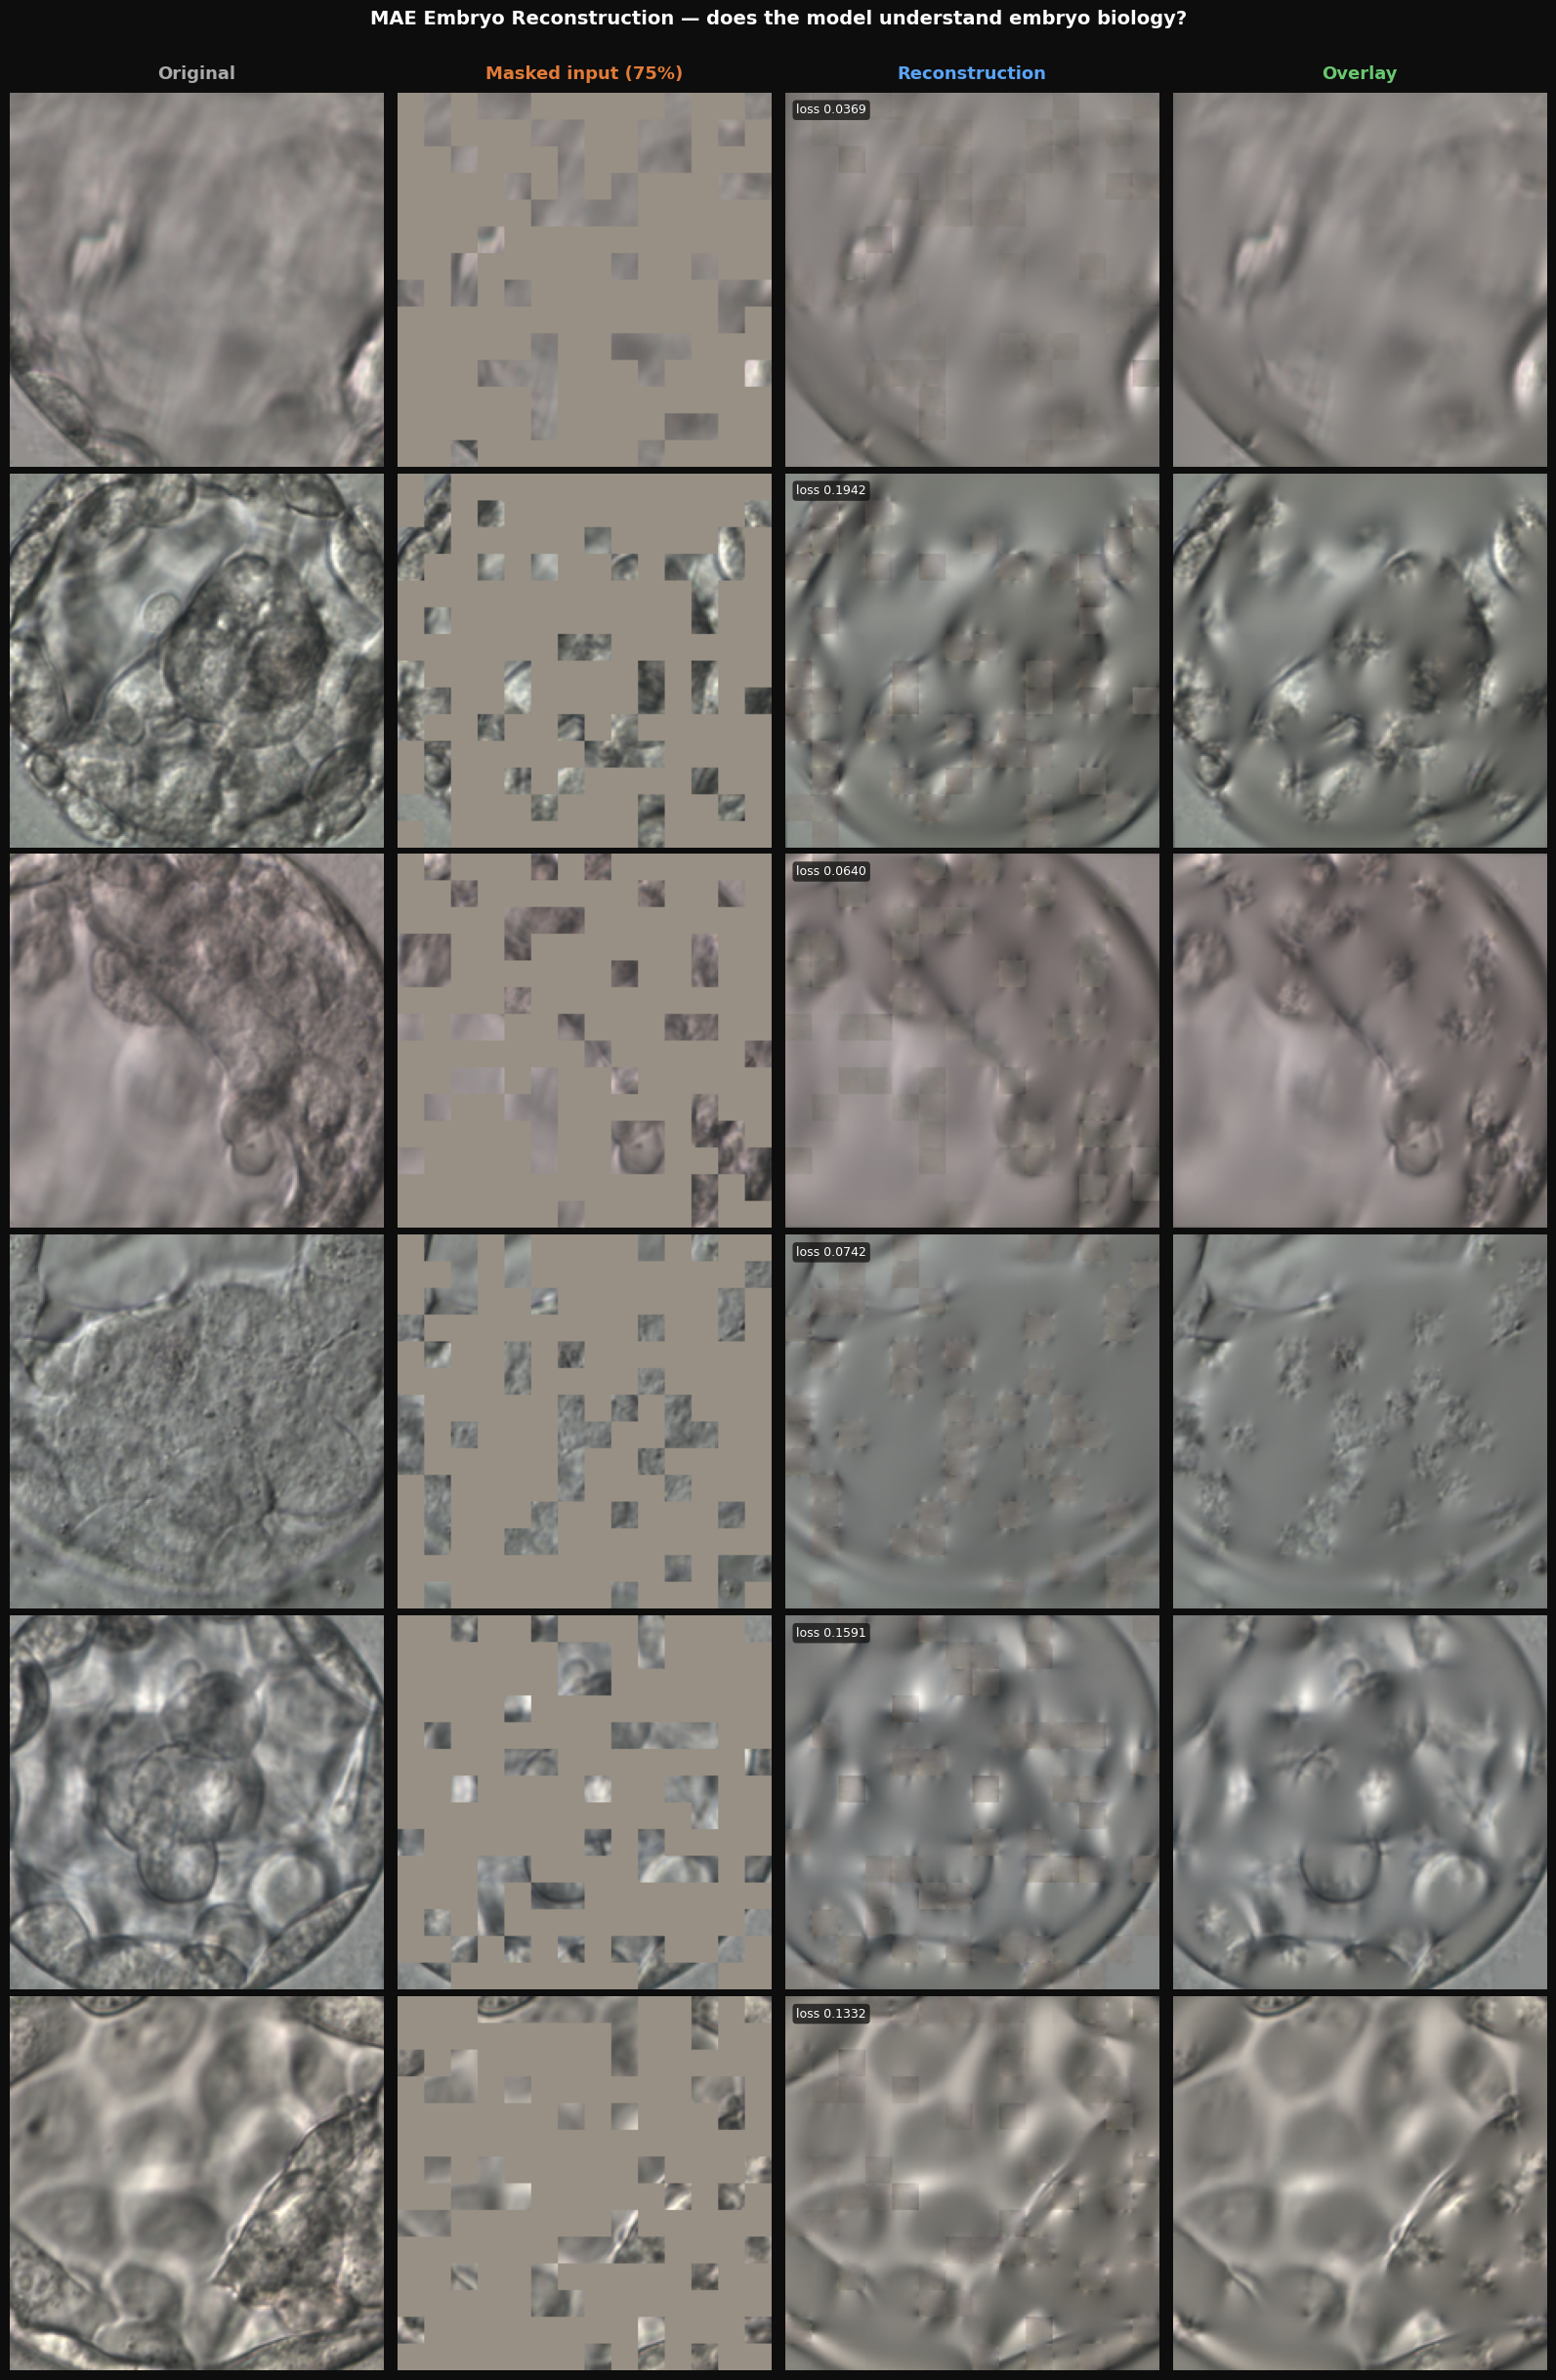


Saved → /content/drive/MyDrive/embryo_mae/mae_reconstruction_grid.png

── Reconstruction quality ──────────────────────
  Avg loss across 6 images : 0.1196
  Min loss (easiest image)             : 0.0493
  Max loss (hardest image)             : 0.1879

  Verdict: Fair — rough outlines recovered, consider more epochs.
──────────────────────────────────────────────



In [ ]:
# ============================================================
# MAE RECONSTRUCTION VISUALIZER
# Paste this into a new Colab cell and run it after training.
# Shows: Original | Masked Input | Reconstruction | Overlay
# ============================================================

import torch
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import random

from PIL import Image
from torchvision import transforms
from transformers import ViTMAEForPreTraining

# ── Config ────────────────────────────────────────────────────
SAVE_DIR   = "/content/drive/MyDrive/embryo_mae"
CKPT_PATH  = f"{SAVE_DIR}/best_mae_full_model.pth"
DATASET_PATH = CFG.DATASET_PATH   # reuse CFG from training cells
DEVICE     = CFG.DEVICE

NUM_IMAGES = 6          # how many embryos to reconstruct
MASK_RATIO = 0.75       # must match training (default 0.75)
SEED       = 42
# ──────────────────────────────────────────────────────────────

random.seed(SEED)
torch.manual_seed(SEED)

# ── 1. Load the full MAE model from best checkpoint ───────────
print("Loading best MAE checkpoint...")
model = ViTMAEForPreTraining.from_pretrained("facebook/vit-mae-base")

ckpt = torch.load(CKPT_PATH, map_location=DEVICE, weights_only=True)
state_dict = ckpt["model_state_dict"] if "model_state_dict" in ckpt else ckpt
model.load_state_dict(state_dict)
model = model.to(DEVICE)
model.eval()
print("Model ready.\n")

# ── 2. Inference transform (no augmentation — deterministic) ──
infer_transform = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std =[0.229, 0.224, 0.225],
    ),
])

# ── 3. Denormalise helper ──────────────────────────────────────
MEAN = torch.tensor([0.485, 0.456, 0.406])
STD  = torch.tensor([0.229, 0.224, 0.225])

def denorm(tensor):
    """(C,H,W) normalised → (H,W,C) uint8 numpy"""
    t = tensor.cpu() * STD[:, None, None] + MEAN[:, None, None]
    t = t.clamp(0, 1).permute(1, 2, 0).numpy()
    return (t * 255).astype(np.uint8)

# ── 4. Reconstruct one image ───────────────────────────────────
def reconstruct(image_tensor):
    """
    Returns:
        original_np   – (224,224,3) uint8 — the clean image
        masked_np     – (224,224,3) uint8 — visible patches only
        recon_np      – (224,224,3) uint8 — full reconstruction
        overlay_np    – (224,224,3) uint8 — recon patches on original
        loss          – scalar reconstruction loss
    """
    pixel_values = image_tensor.unsqueeze(0).to(DEVICE)

    with torch.no_grad():
        outputs = model(pixel_values=pixel_values)

    loss    = outputs.loss.item()
    logits  = outputs.logits          # (1, num_patches, patch_size²×3)
    mask    = outputs.mask            # (1, num_patches)  1=masked

    # ── Unpatchify reconstruction ──────────────────────────────
    recon_patches = model.unpatchify(logits)   # (1,3,224,224)
    recon_patches = recon_patches.squeeze(0)   # (3,224,224)

    # ── Build masked-input view ────────────────────────────────
    # Upscale patch mask to pixel mask
    patch_size = model.config.patch_size           # 16
    num_patches_side = 224 // patch_size           # 14

    # mask shape: (1, 196)  →  (14,14) → (224,224)
    mask_2d = mask.squeeze(0).reshape(
        num_patches_side, num_patches_side
    )                                              # (14,14)
    mask_pixel = mask_2d.repeat_interleave(
        patch_size, dim=0
    ).repeat_interleave(
        patch_size, dim=1
    )                                              # (224,224)
    mask_pixel = mask_pixel.cpu()                  # 1=masked

    orig_cpu = image_tensor.cpu()

    # masked input: original where visible, grey where masked
    masked = orig_cpu.clone()
    masked[:, mask_pixel == 1] = 0.5              # grey masked patches

    # overlay: original where visible, reconstruction where masked
    overlay = orig_cpu.clone()
    overlay[:, mask_pixel == 1] = recon_patches.cpu()[:, mask_pixel == 1]

    return (
        denorm(orig_cpu),
        denorm(masked),
        denorm(recon_patches),
        denorm(overlay),
        loss,
    )

# ── 5. Sample random images ────────────────────────────────────
import os
valid_ext = {".jpg", ".jpeg", ".png", ".bmp"}
all_paths = [
    os.path.join(DATASET_PATH, f)
    for f in os.listdir(DATASET_PATH)
    if os.path.splitext(f.lower())[1] in valid_ext
]
sampled = random.sample(all_paths, min(NUM_IMAGES, len(all_paths)))
print(f"Reconstructing {len(sampled)} embryo images...\n")

# ── 6. Plot ────────────────────────────────────────────────────
fig, axes = plt.subplots(
    len(sampled), 4,
    figsize=(16, 4 * len(sampled)),
    facecolor="#0d0d0d",
)

col_titles = ["Original", "Masked input (75%)", "Reconstruction", "Overlay"]
col_colors = ["#aaaaaa", "#e07b39", "#5ba4f5", "#69c76f"]

for col, (title, color) in enumerate(zip(col_titles, col_colors)):
    axes[0][col].set_title(title, color=color, fontsize=13,
                           fontweight="bold", pad=10)

for row, path in enumerate(sampled):
    img = Image.open(path).convert("RGB")
    tensor = infer_transform(img)

    orig, masked, recon, overlay, loss = reconstruct(tensor)

    panels = [orig, masked, recon, overlay]

    for col, panel in enumerate(panels):
        ax = axes[row][col]
        ax.imshow(panel)
        ax.axis("off")

        # loss badge on reconstruction panel
        if col == 2:
            ax.text(
                0.03, 0.97, f"loss {loss:.4f}",
                transform=ax.transAxes,
                fontsize=9, color="white",
                va="top", ha="left",
                bbox=dict(boxstyle="round,pad=0.3",
                          facecolor="#111111", alpha=0.75, linewidth=0),
            )

    # row label (filename)
    fname = os.path.basename(path)[:28]
    axes[row][0].set_ylabel(
        fname, color="#888888", fontsize=8,
        rotation=0, labelpad=80, va="center"
    )

# colour-coded column separators
for ax_row in axes:
    for ax in ax_row:
        for spine in ax.spines.values():
            spine.set_visible(False)

plt.suptitle(
    "MAE Embryo Reconstruction — does the model understand embryo biology?",
    color="white", fontsize=14, y=1.01, fontweight="bold"
)
plt.tight_layout(pad=0.5)
plt.savefig(
    f"{SAVE_DIR}/mae_reconstruction_grid.png",
    dpi=150, bbox_inches="tight",
    facecolor="#0d0d0d"
)
plt.show()
print(f"\nSaved → {SAVE_DIR}/mae_reconstruction_grid.png")

# ── 7. Quality verdict ─────────────────────────────────────────
losses = []
for path in sampled:
    t = infer_transform(Image.open(path).convert("RGB"))
    with torch.no_grad():
        out = model(t.unsqueeze(0).to(DEVICE))
    losses.append(out.loss.item())

avg = sum(losses) / len(losses)
print("\n── Reconstruction quality ──────────────────────")
print(f"  Avg loss across {len(sampled)} images : {avg:.4f}")
print(f"  Min loss (easiest image)             : {min(losses):.4f}")
print(f"  Max loss (hardest image)             : {max(losses):.4f}")

if avg < 0.08:
    verdict = "Excellent — the model clearly understands embryo structure."
elif avg < 0.10:
    verdict = "Good — key structures visible, minor blurring expected."
elif avg < 0.13:
    verdict = "Fair — rough outlines recovered, consider more epochs."
else:
    verdict = "Poor — reconstructions are blurry blobs, needs more training."

print(f"\n  Verdict: {verdict}")
print("──────────────────────────────────────────────\n")